In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('../data/train.csv')

In [4]:
print(df.shape)        # how many rows and columns
print(df.columns)      # column names
df.head()              # first 5 rows

(45000, 6)
Index(['Id', 'Title', 'Body', 'Tags', 'CreationDate', 'Y'], dtype='object')


,Id,Title,Body,Tags,CreationDate,Y
0,34552656,Java: Repeat Task Every Random Seconds,<p>I'm already familiar with repeating tasks e...,<java><repeat>,2016-01-01 00:21:59,LQ_CLOSE
1,34553034,Why are Java Optionals immutable?,<p>I'd like to understand why Java 8 Optionals...,<java><optional>,2016-01-01 02:03:20,HQ
2,34553174,Text Overlay Image with Darkened Opacity React...,<p>I am attempting to overlay a title over an ...,<javascript><image><overlay><react-native><opa...,2016-01-01 02:48:24,HQ
3,34553318,Why ternary operator in swift is so picky?,"<p>The question is very simple, but I just cou...",<swift><operators><whitespace><ternary-operato...,2016-01-01 03:30:17,HQ
4,34553755,hide/show fab with scale animation,<p>I'm using custom floatingactionmenu. I need...,<android><material-design><floating-action-but...,2016-01-01 05:21:48,HQ


In [5]:
# How many of each quality class do you have?
print(df['Y'].value_counts())
print(df['Y'].value_counts(normalize=True) * 100)

Y
LQ_CLOSE    15000
HQ          15000
LQ_EDIT     15000
Name: count, dtype: int64
Y
LQ_CLOSE    33.333333
HQ          33.333333
LQ_EDIT     33.333333
Name: proportion, dtype: float64


In [6]:
# Read 3 HQ questions manually
hq = df[df['Y'] == 'HQ'].sample(3)
for _, row in hq.iterrows():
    print("TITLE:", row['Title'])
    print("BODY:", row['Body'][:500])
    print("---")

TITLE: How to update the Redux store after Apollo GraphQL query returns
BODY: <p>I'm fetching a list of data with the <code>graphql</code> HOC provided by react apollo. E.g.:</p>

<pre><code>const fetchList = graphql(
  dataListQuery, {
    options: ({ listId }) =&gt; ({
      variables: {
        listId,
      },
    }),
    props: ({ data: { loading, dataList } }) =&gt; {
      return {
        loading,
        list: dataList,
      };
    }
  }
);
</code></pre>

<p>I'm displaying the list in a controlled radio button group and I need to select one of the items by defau
---
TITLE: Python - unpacking kwargs in local function call
BODY: <p>I would like to pass a <code>dictionary</code>:</p>

<pre><code>items = {"artist": "Radiohead", "track": "Karma Police"}
</code></pre>

<p>as a parameter to this <code>function</code>:</p>

<pre><code>def lastfm_similar_tracks(**kwargs):

    result = last.get_track(kwargs)
    st = dict(str(item[0]).split(" - ") for item in result.get_similar())
   

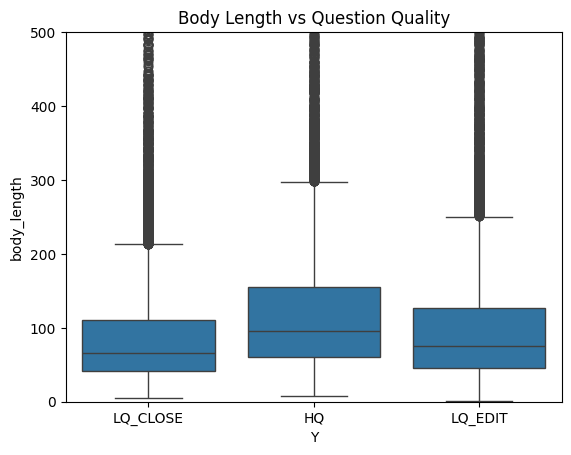

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Does length actually separate quality classes?
df['body_length'] = df['Body'].apply(
    lambda x: len(str(x).split()))

sns.boxplot(data=df, x='Y', y='body_length')
plt.title('Body Length vs Question Quality')
plt.ylim(0, 500)  # cap outliers for visibility
plt.show()